In [1]:
import pandas as pd
import os
import random
import chardet
import requests
import json
import numpy as np
from urllib3.util.retry import Retry
import openai
from requests.adapters import HTTPAdapter
import os
import pickle
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [2]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_dict_fix_window_1s_102movies.pkl', 'rb') as f:
    scores_dict = pickle.load(f)

In [3]:
file_list = list(scores_dict.keys())

In [4]:
# scores_all = np.zeros((0,6))
# n_samples = np.zeros(len(file_list))
# scores_dict = {}
# failed_counts_dict = {}
time_points_dict = {}

In [5]:
for i in range(len(file_list)):
    scores = scores_dict[file_list[i]]
    time_points_dict[file_list[i]] = np.arange(scores.shape[0])

In [6]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_dict_fix_window_1s_102movies.pkl', 'wb') as f:
    pickle.dump(time_points_dict, f)

In [7]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
    scores_ori = pickle.load(f)
    
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\times_allMovies_resample.pkl', 'rb') as f:
    times_ori = pickle.load(f)

print(scores_ori.keys())

dict_keys(['Batman_darknight', 'Be_somebody', 'forrest_gump', 'Gashapon', 'Godzilla', 'Green_book', 'Harry_potter', 'Heidi', 'Kong_fu', 'let_bullet_fly_reorder', 'Luo_xiao_hei', 'The_bad_guys', 'The_Shawshank_Redemption', 'The_Wandering_Earth_II', 'Weathering_With_You', 'White_snake', 'World_War_Z', 'Yang_jian', 'BV1134y1g7Vq', 'BV11x4y117NY', 'BV147411y71D', 'BV14b411c72z', 'BV14E411C7Lf', 'BV14T4y1u7ST', 'BV163411i7Un', 'BV164411k73g', 'BV16e4y1P7sa', 'BV17f4y1n7et', 'BV17h411D7aX', 'BV17W411r78v', 'BV17W411Z7Lh', 'BV18E411e7By', 'BV191421B7B9', 'BV19x41127Nd', 'BV1BJ411S7Ch', 'BV1bL411578p', 'BV1bz4y1a7QZ', 'BV1cW411a7ed', 'BV1Ds411V7cP', 'BV1dU4y1g73N', 'BV1Dx411u7jw', 'BV1e4411k74a', 'BV1E4411U7Qu', 'BV1ED4y1j7Jn', 'BV1Ee4y1B74h', 'BV1eJ411B7to', 'BV1Fb411F7fk', 'BV1Fb411z7Zy', 'BV1ht4y1D7tG', 'BV1j4411X7CV', 'BV1j44y1y7YQ', 'BV1kJ411j7pH', 'BV1kK4y1b7dH', 'BV1Kx411p7hz', 'BV1ky4y167Tg', 'BV1Lp411R7Fx', 'BV1LP4y1H7TJ', 'BV1M7411J7kP', 'BV1ms411U75B', 'BV1mw4m1e7BD', 'BV1na4y1Y7rR'

In [8]:
movie_names_eng = [
    "Batman Dark Knight",
    "Be Somebody",
    "Forrest Gump",
    "Big World Gashapon",
    "Godzilla",
    "Green Book",
    "Harry Potter and the Goblet of Fire",
    "Heidi",
    "Kung Fu",
    "Let the Bullets Fly",
    "The Legend of Luo Xiaohei",
    "The Bad Guys",
    "The Shawshank Redemption",
    "The Wandering Earth II",
    "Weathering With You",
    "White Snake",
    "World War Z",
    "Yang Jian",
    "Suzume",  # 铃芽之旅
    "Johnny Keep Walking!",  # 年会不能停!
    "The Lord of the Rings: The Fellowship of the Ring",  # 指环王1
    "The SpongeBob SquarePants Movie",  # 海绵宝宝历险记
    "Our Fathers",  # 我们的父辈
    "Detective Conan: The Phantom of Baker Street",  # 名侦探柯南
    "Love Letter",  # 情书
    "Harry Potter and the Order of the Phoenix",
    "Detective Conan: The Bride of Halloween",
    "White Snake 2: The Tribulation of Green Snake",
    "New Gods: Nezha Reborn",
    "The Truman Show",  # 楚门的世界
    "Transformers",
    "Flipped",  # 怦然心动
    "The Pig, the Snake and the Pigeon",  # 周处除三害
    "Date A Live Movie: Mayuri Judgment",
    "Rascal Does Not Dream of a Dreaming Girl",
    "Violet Evergarden: The Movie",
    "Journey to the West",  # 宇宙探索编辑部
    "Sword Art Online: Ordinal Scale",  # 刀剑神域
    "Overlord: The Dark Hero",
    "Rurouni Kenshin",  # 浪客剑心
    "A Silent Voice",  # 声之形
    "Harry Potter and the Half-Blood Prince",
    "Harry Potter and the Chamber of Secrets",
    "Still Miss You",  # 还是觉得你最好
    "Ready Player One",  # 头号玩家
    "Edge of Tomorrow",  # 明日边缘
    "Transformers: Revenge of the Fallen",
    "Fate/stay night: Heaven's Feel I. presage flower",
    "Fantastic Beasts and Where to Find Them",
    "Harry Potter and the Sorcerer's Stone",
    "Promare",  # 普罗米亚
    "Fireworks",  # 烟花
    "Goodbye Mr. Loser",  # 夏洛特烦恼
    "Tamako Love Story",  # 玉子爱情故事
    "Leap",  # 夺冠
    "A Little Thing Called Love",  # 初恋这件小事
    "The Legend of Sealed Book",  # 天书奇谭
    "The SpongeBob Movie: Sponge Out of Water",  # 海绵宝宝水兵陆战队
    "The Garden of Words",  # 言叶之庭
    "Kowloon Walled City",  # 九龙城寨
    "The Silence of the Lambs",
    "Inception",  # 盗梦空间
    "Interstellar",
    "Deep Sea",  # 深海
    "Jiang Ziya",  # 姜子牙
    "Harry Potter and the Deathly Hallows Part 2",
    "CJ7",  # 长江七号
    "Lost on Journey",  # 人在囧途
    "Only Fools Rush In",  # 四海
    "Five Hundred Miles",  # 交换人生
    "The Godfather",
    "Harry Potter and the Prisoner of Azkaban",
    "Minions",  # 小黄人大眼萌
    "Violet Evergarden: Eternity and the Auto Memories Doll",
    "One Second",  # 一秒钟
    "Sword Art Online Progressive: Aria of a Starless Night",
    "Catch Me If You Can",  # 猫鼠游戏
    "Wolf Warrior",  # 战狼
    "Brotherhood of Blades",  # 绣春刀
    "Hidden Blade",  # 无名
    "Endless Journey",  # 三大队
    "Pegasus 2",  # 飞驰人生2
    "Evangelion: 2.22 You Can (Not) Advance",
    "Evangelion: 3.33 You Can (Not) Redo",
    "Evangelion: 1.11 You Are (Not) Alone",
    "Evangelion: Death and Rebirth",
    "Crazy Racer",  # 疯狂的赛车
    "My Little Pony Equestria Girls: Friendship Games",  # 彩虹小马
    "My Own Swordsman",  # 武林外传
    "Words Bubble Up Like Soda Pop",  # 言语如苏打般涌现
    "No Time to Die",  # 007
    "Overlord: The Undead King",
    "5 Centimeters Per Second",  # 秒速5厘米
    "Win the Kids",  # 抓娃娃
    "The Founding of a Republic",  # 建国大业
    "Ip Man",  # 叶问
    "The King's Avatar: For the Glory",  # 全职高手
    "Shin Ultraman",  # 新·奥特曼
    "Pleasant Goat and Big Big Wolf: Dunk for Future",  # 喜羊羊
    "One Piece Film: Red",  # 航海王
    "Johnny English",  # 憨豆特工
    "Pacific Rim"  # 环太平洋
]

In [9]:
print(scores_dict.keys())
print(len(movie_names_eng), len(scores_dict.keys()))

dict_keys(['5_Centimeters_Per_Second', 'A_Little_Thing_Called_Love', 'A_Silent_Voice', 'Batman_Dark_Knight', 'Be_Somebody', 'Big_World_Gashapon', 'Brotherhood_Of_Blades', 'Catch_Me_If_You_Can', 'Cj7', 'Crazy_Racer', 'Date_A_Live_Movie\uf022_Mayuri_Judgment', 'Deep_Sea', 'Detective_Conan\uf022_The_Bride_Of_Halloween', 'Detective_Conan\uf022_The_Phantom_Of_Baker_Street', 'Edge_Of_Tomorrow', 'Endless_Journey', 'Evangelion\uf022_1', 'Evangelion\uf022_2', 'Evangelion\uf022_3', 'Evangelion\uf022_Death_And_Rebirth', 'Fantastic_Beasts_And_Where_To_Find_Them', "Fate_Stay_Night\uf022_Heaven'S_Feel_I", 'Fireworks', 'Five_Hundred_Miles', 'Flipped', 'Godzilla', 'Goodbye_Mr', 'Green_Book', 'Harry_Potter_And_The_Chamber_Of_Secrets', 'Harry_Potter_And_The_Deathly_Hallows_Part_2', 'Harry_Potter_And_The_Goblet_Of_Fire', 'Harry_Potter_And_The_Half-Blood_Prince', 'Harry_Potter_And_The_Order_Of_The_Phoenix', 'Harry_Potter_And_The_Prisoner_Of_Azkaban', "Harry_Potter_And_The_Sorcerer'S_Stone", 'Heidi', 'Hidd

In [10]:
import re
import unicodedata
import difflib
import pandas as pd

def normalize_title(s):
    s = str(s)
    s = s.replace('\uf022', ' ')  
    s = s.replace('_', ' ')
    s = unicodedata.normalize('NFKD', s)
    s = s.lower()
    s = s.replace('&', ' and ')
    s = re.sub(r"[^a-z0-9]+", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# manual_map = {
#     "BV1zW411d7Rb": "Forrest Gump"
# }

def best_match_key_to_movie(key, movie_names_eng, threshold=0.85):
    # query = manual_map.get(key, key)
    q_norm = normalize_title(key)

    movie_norms = [normalize_title(x) for x in movie_names_eng]
    scores = [
        difflib.SequenceMatcher(None, q_norm, m_norm).ratio()
        for m_norm in movie_norms
    ]

    best_idx = int(max(range(len(scores)), key=lambda i: scores[i]))
    best_score = scores[best_idx]

    if best_score < threshold:
        return None, None, best_score

    return best_idx, movie_names_eng[best_idx], best_score


keys = list(scores_dict.keys())   

rows = []
matched_indices = []

for key in keys:
    idx, matched_name, score = best_match_key_to_movie(
        key, movie_names_eng, threshold=0.85
    )
    matched_indices.append(idx)
    rows.append({
        "key": key,
        "matched_index": idx,
        "matched_movie": matched_name,
        "score": score
    })

match_df = pd.DataFrame(rows)
print(match_df)

                               key  matched_index  \
0         5_Centimeters_Per_Second           92.0   
1       A_Little_Thing_Called_Love           55.0   
2                   A_Silent_Voice           40.0   
3               Batman_Dark_Knight            0.0   
4                      Be_Somebody            1.0   
..                             ...            ...   
97                    Wolf_Warrior           77.0   
98   Words_Bubble_Up_Like_Soda_Pop           89.0   
99                     World_War_Z           16.0   
100                      Yang_Jian           17.0   
101                   Forrest_Gump            2.0   

                     matched_movie  score  
0         5 Centimeters Per Second    1.0  
1       A Little Thing Called Love    1.0  
2                   A Silent Voice    1.0  
3               Batman Dark Knight    1.0  
4                      Be Somebody    1.0  
..                             ...    ...  
97                    Wolf Warrior    1.0  
98   Words 

In [11]:
matched_index = np.array(match_df['matched_index'])

In [12]:
matched_index[16] = 84.0
matched_index[17] = 82.0
matched_index[18] = 83.0
matched_index[21] = 47.0
matched_index[26] = 52.0

In [13]:
np.where(np.isnan(matched_index))

(array([], dtype=int64),)

In [14]:
print(keys[16], keys[17], keys[18], keys[21], keys[26])

Evangelion_1 Evangelion_2 Evangelion_3 Fate_Stay_Night_Heaven'S_Feel_I Goodbye_Mr


In [15]:
len(np.unique(matched_index))

102

In [16]:
file_names = list(scores_dict.keys())

In [17]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from scipy.stats import norm
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter1d
import numpy as np

import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

def weighted_smooth_seconds(emotions, counts, sigma=3, min_effective_weight=0.0):
    """    
    Parameters:
    -----------
    emotions : ndarray, shape (n_seconds, 6)
    counts : ndarray, shape (n_seconds,)
    sigma : float
    min_effective_weight : float
        
    Returns:
    --------
    smoothed : ndarray, shape (n_seconds, 6)
    confidence : ndarray, shape (n_seconds,)
    """
    n_seconds, n_dims = emotions.shape
    smoothed = np.zeros_like(emotions)
    
    radius = int(5 * sigma)
    x = np.arange(-radius, radius + 1)
    kernel = np.exp(-0.5 * (x / sigma) ** 2)

    confidences = np.zeros((n_seconds, n_dims))
    
    for dim in range(n_dims):
        values = emotions[:, dim]
        valid_mask = ~np.isnan(values)
        
        effective_counts = counts * valid_mask
        safe_values = np.where(valid_mask, values, 0)
        
        numerator = np.convolve(safe_values * effective_counts, kernel, mode='same')
        denominator = np.convolve(effective_counts, kernel, mode='same')
        
        confidences[:, dim] = denominator
        
        with np.errstate(divide='ignore', invalid='ignore'):
            # 条件：denominator >= min_effective_weight
            smoothed[:, dim] = np.where(
                denominator >= min_effective_weight, 
                numerator / denominator, 
                np.nan
            )
    
    confidence = np.mean(confidences, axis=1)
    
    return smoothed, confidence



def plot_emotion_timeline(time_points, raw_emotions, smoothed_emotions, counts, 
                          emotion_names=None, figsize=(15, 10)):
    """
    Visualize emotion smoothing effects
    """
    if emotion_names is None:
        emotion_names = ['Joy', 'Anger', 'Sadness', 'Fear', 'Disgust', 'Surprise']
    
    fig, axes = plt.subplots(3, 2, figsize=figsize)
    axes = axes.flatten()
    
    for i in range(6):
        ax = axes[i]
        
        # Plot raw data (scatter size represents danmu count)
        scatter = ax.scatter(time_points, raw_emotions[:, i], 
                           c='lightblue', s=counts*2, alpha=0.6, label='Raw Data')
        
        # Plot smoothed curve
        ax.plot(time_points, smoothed_emotions[:, i], 
                color='red', linewidth=2, label='Gaussian Smoothing (σ=3s)')
        
        ax.set_title(emotion_names[i])
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Emotion Intensity')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Add danmu count subplot at the bottom
    # Note: This creates a new axes spanning the bottom of the figure
    # fig, axes = plt.subplots(1, 1)
    fig2, ax_counts = plt.subplots(figsize=(16, 3))
    plt.plot(time_points, counts, linewidth=0.2)
    ax_counts.bar(time_points, counts, width=0.8, alpha=0.5, color='gray')
    ax_counts.set_xlabel('Time (s)')
    ax_counts.set_ylabel('Danmu Count')
    ax_counts.set_title('Danmu Count Distribution (as Smoothing Confidence)')
    
    plt.tight_layout()
    plt.show()
    return fig, fig2



def process_danmu_emotions(df, time_col='time', count_col='count', 
                           emotion_cols=None, sigma=3, min_effective_weight=1.0):
    """
    主处理函数
    """
    if emotion_cols is None:
        emotion_cols = [c for c in df.columns if any(e in c for e in 
                       ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear',
                        '高兴', '惊讶', '悲伤', '愤怒', '厌恶', '恐惧'])]
        if len(emotion_cols) != 6:
            # 如果没识别到，取前6个数值列（排除time和count）
            numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
            numeric_cols.remove(time_col)
            numeric_cols.remove(count_col)
            emotion_cols = numeric_cols[:6]
    
    print(f"Identified emotion dimensions: {emotion_cols}")
    
    time_points = df[time_col].values
    counts = df[count_col].values
    emotions = df[emotion_cols].values
    
    smoothed, confidence = weighted_smooth_seconds(emotions, counts, sigma=sigma, min_effective_weight=min_effective_weight)
    
    return smoothed, confidence

In [ ]:
danmu_number_dict = {}
for i in range(len(file_names)):
    bv_name = file_names[i]
    with open(os.path.join(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Processed_danmu_fixwindow', 'danmu_%s_downsample_fixwindow.pkl' % bv_name), 'rb') as f:
        data = pickle.load(f)
    print(bv_name)
    danmu = data[list(data.keys())[0]] 
    danmu_number = []
    for i in range(len(danmu)):
        danmu_number.append(len(danmu[i].splitlines()))
    danmu_number = np.array(danmu_number)
    print(np.min(danmu_number), np.median(danmu_number))
    danmu_number_dict[bv_name] = danmu_number

5_Centimeters_Per_Second
0 20.0
A_Little_Thing_Called_Love
0 14.0
A_Silent_Voice
1 20.0
Batman_Dark_Knight
0 11.0
Be_Somebody
0 18.0
Big_World_Gashapon
0 2.0
Brotherhood_Of_Blades
0 15.0
Catch_Me_If_You_Can
0 8.0
Cj7
0 4.0
Crazy_Racer
0 6.0
Date_A_Live_Movie_Mayuri_Judgment
0 20.0
Deep_Sea
0 4.0
Detective_Conan_The_Bride_Of_Halloween
0 5.0
Detective_Conan_The_Phantom_Of_Baker_Street
0 11.0
Edge_Of_Tomorrow
0 7.0
Endless_Journey
0 4.0
Evangelion_1
0 7.0
Evangelion_2
0 10.0
Evangelion_3
0 9.0
Evangelion_Death_And_Rebirth
0 2.0
Fantastic_Beasts_And_Where_To_Find_Them
0 12.0
Fate_Stay_Night_Heaven'S_Feel_I
1 20.0
Fireworks
0 14.0
Five_Hundred_Miles
0 2.0
Flipped
0 18.0
Godzilla
0 13.0
Goodbye_Mr
0 15.0
Green_Book
0 15.0
Harry_Potter_And_The_Chamber_Of_Secrets
0 11.0
Harry_Potter_And_The_Deathly_Hallows_Part_2
0 14.0
Harry_Potter_And_The_Goblet_Of_Fire
0 20.0
Harry_Potter_And_The_Half-Blood_Prince
0 20.0
Harry_Potter_And_The_Order_Of_The_Phoenix
0 20.0
Harry_Potter_And_The_Prisoner_

In [20]:
scores_smoothed_dict = {}
for i in range(len(file_names)):
    scores_now = scores_dict[file_names[i]]
    time_points = time_points_dict[file_names[i]]
    danmu_number = danmu_number_dict[file_names[i]]
    data = {
        'time': time_points,
        'count': danmu_number,
        'happiness': scores_now[:,0],
        'surprise': scores_now[:,1],
        'sadness': scores_now[:,2],
        'anger': scores_now[:,3],
        'disgust': scores_now[:,4],
        'fear': scores_now[:,5],
    }
    df = pd.DataFrame(data)
    scores_smoothed, confidence = process_danmu_emotions(df, time_col='time', count_col='count', 
                           emotion_cols=None, sigma=3, min_effective_weight=0.0)
    scores_smoothed = scores_smoothed[::2, :]
    scores_smoothed_dict[file_names[i]] = scores_smoothed
    

Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happiness', 'surprise', 'sadness', 'anger', 'disgust', 'fear']
Identified emotion dimensions: ['happine

In [ ]:
# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_dict_fix_window_1s_102movies.pkl', 'rb') as f:
#     scores_dict = pickle.load(f)
# with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_smoothed_dict_fix_window_1s_102movies.pkl', 'rb') as f:
#     scores_smoothed_dict = pickle.load(f)

In [21]:
with open(r'\\10.16.57.94\dataset1\xinke\Danmu\DyEmo-submit\DyEmo-FullMovies\Emotion_scores\scores_allMovies_resample.pkl', 'rb') as f:
    scores_ori = pickle.load(f)

In [22]:
keys = list(scores_smoothed_dict.keys())
print(keys)
keys_ori = list(scores_ori.keys())
print(keys_ori)
rs = np.zeros((102,6))
for i in range(102):
    print(keys[i], keys_ori[int(matched_index[i])])
    scores_now = scores_smoothed_dict[keys[i]]
    scores_now_resample = scores_now
    scores_now_ori = scores_ori[keys_ori[int(matched_index[i])]]
    print(scores_now_resample.shape, scores_now_ori.shape)
    
    cut_ind = np.min([scores_now_resample.shape[0], scores_now_ori.shape[0]])
    scores_now_resample = scores_now_resample[:cut_ind,:]
    scores_now_ori = scores_now_ori[:cut_ind,:]
    
    for k in range(6):
        rs[i,k] = np.corrcoef(scores_now_resample[:,k], scores_now_ori[:,k])[0,1]
print(rs)

['5_Centimeters_Per_Second', 'A_Little_Thing_Called_Love', 'A_Silent_Voice', 'Batman_Dark_Knight', 'Be_Somebody', 'Big_World_Gashapon', 'Brotherhood_Of_Blades', 'Catch_Me_If_You_Can', 'Cj7', 'Crazy_Racer', 'Date_A_Live_Movie\uf022_Mayuri_Judgment', 'Deep_Sea', 'Detective_Conan\uf022_The_Bride_Of_Halloween', 'Detective_Conan\uf022_The_Phantom_Of_Baker_Street', 'Edge_Of_Tomorrow', 'Endless_Journey', 'Evangelion\uf022_1', 'Evangelion\uf022_2', 'Evangelion\uf022_3', 'Evangelion\uf022_Death_And_Rebirth', 'Fantastic_Beasts_And_Where_To_Find_Them', "Fate_Stay_Night\uf022_Heaven'S_Feel_I", 'Fireworks', 'Five_Hundred_Miles', 'Flipped', 'Godzilla', 'Goodbye_Mr', 'Green_Book', 'Harry_Potter_And_The_Chamber_Of_Secrets', 'Harry_Potter_And_The_Deathly_Hallows_Part_2', 'Harry_Potter_And_The_Goblet_Of_Fire', 'Harry_Potter_And_The_Half-Blood_Prince', 'Harry_Potter_And_The_Order_Of_The_Phoenix', 'Harry_Potter_And_The_Prisoner_Of_Azkaban', "Harry_Potter_And_The_Sorcerer'S_Stone", 'Heidi', 'Hidden_Blade',

In [ ]:
# print(np.mean(rs, axis=0), np.std(rs, axis=0))

[0.77693488 0.59091539 0.83201662 0.75932899 0.7298821  0.76113112] [0.08290963 0.12587911 0.07455753 0.10906746 0.11647703 0.11016657]


In [23]:
z_values = np.arctanh(rs)
z_mean = np.nanmean(z_values, axis=0)
z_sd = np.nanstd(z_values, axis=0, ddof=1)

r_mean = np.tanh(z_mean)

# 把 z_mean ± z_sd 反变换成 r 空间的不对称范围
r_lower = np.tanh(z_mean - z_sd)
r_upper = np.tanh(z_mean + z_sd)

emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
for i, name in enumerate(emos):
    print(
        f"{name}: "
        f"mean r = {r_mean[i]:.3f}, "
        f"Fisher z = {z_mean[i]:.3f} ± {z_sd[i]:.3f}, "
        f"corresponding r range = [{r_lower[i]:.3f}, {r_upper[i]:.3f}]"
    )

Happiness: mean r = 0.791, Fisher z = 1.075 ± 0.228, corresponding r range = [0.689, 0.863]
Surprise: mean r = 0.608, Fisher z = 0.706 ± 0.219, corresponding r range = [0.452, 0.728]
Sadness: mean r = 0.847, Fisher z = 1.245 ± 0.254, corresponding r range = [0.758, 0.905]
Anger: mean r = 0.782, Fisher z = 1.049 ± 0.279, corresponding r range = [0.647, 0.869]
Disgust: mean r = 0.753, Fisher z = 0.980 ± 0.277, corresponding r range = [0.607, 0.850]
Fear: mean r = 0.782, Fisher z = 1.050 ± 0.264, corresponding r range = [0.656, 0.865]


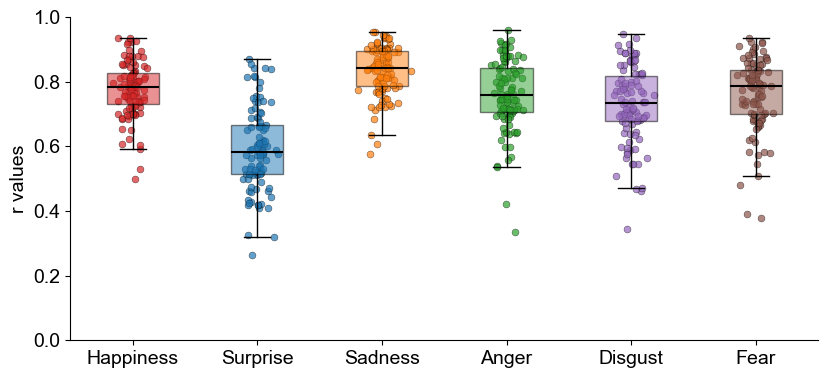

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 假设 r_values 是 shape = (102, 6) 的 numpy array
# 每列分别对应 6 个维度
# 例如：
# r_values = np.array(...)
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 14
colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]

fig, ax = plt.subplots(figsize=(8.5, 4))

# 组织成箱线图输入格式：6个list/array，每个长度102
data_to_plot = [rs[:, i] for i in range(6)]

# 箱线图
box = ax.boxplot(
    data_to_plot,
    patch_artist=True,
    widths=0.42,
    showfliers=False
)

# 设置每个箱体颜色
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
    patch.set_edgecolor('black')

for median in box['medians']:
    median.set_color('black')
    median.set_linewidth(1.5)

for whisker in box['whiskers']:
    whisker.set_color('black')

for cap in box['caps']:
    cap.set_color('black')

# 叠加散点
np.random.seed(42)  # 保证抖动可复现
for i in range(6):
    y = rs[:, i]
    x = np.random.normal(loc=i+1, scale=0.06, size=len(y))  # 横向轻微抖动
    ax.scatter(
        x, y,
        s=25,
        color=colors[i],
        alpha=0.7,
        edgecolors='black',
        linewidths=0.3
    )

ax.set_xticks(range(1, 7))
ax.set_xticklabels(emos, fontsize=14)
ax.set_ylabel('r values', fontsize=14)
# ax.set_title('Distribution of r values across 6 dimensions', fontsize=14)
ax.set_ylim([0,1])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('figures/r_values_fix_window_flex_window.jpg')
plt.show()

In [25]:
from scipy.linalg import inv, norm
from scipy.optimize import minimize_scalar
import mou_model as pm

def system_identification(time_series):
    
    mou = pm.MOU()
    mou.fit(time_series, lag = 1)
    Jacobian = np.copy(mou.J)
    Sigma = np.copy(mou.Sigma)
    
    print(' - model fit of empirical covariances: ', end = '')
    print(mou.d_fit['correlation'])
    
    return Jacobian, Sigma

def average_controllability(Jacobian, Sigma):

    integral = -inv(Jacobian + Jacobian.T)
    AC = np.sqrt(np.diag(np.dot(np.dot(Sigma.T, integral), Sigma)))
    
    return AC

def modal_controllability(Jacobian, Sigma):

    n = Jacobian.shape[0]
    MC = np.array([-1/minimize_scalar(lambda omega: -norm(Sigma[i,i]*inv(1j*omega*np.eye(n)-Jacobian)[:,i], 2)).fun for i in range(n)])

    return MC

from scipy.optimize import curve_fit
from scipy import stats
# =========================
# Dynamic feature functions
# =========================

import numpy as np
from scipy.optimize import curve_fit


# =========================
# Same model definitions
# =========================

def exp_decay(x, A, lambda_):
    return A * np.exp(-lambda_ * x)


def power_law(x, A, alpha):
    return A * x ** (-alpha)


def r_squared(y, y_fit):
    y = np.asarray(y, dtype=float)
    y_fit = np.asarray(y_fit, dtype=float)

    ss_res = np.sum((y - y_fit) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)

    if ss_tot == 0 or not np.isfinite(ss_tot):
        return np.nan

    return 1 - ss_res / ss_tot


# =========================
# Exact inertia logic
# =========================

def compute_inertia_segment(
    scores_txe,
    p0_exp=(1, 0.1),
    maxfev=5000
):
    """
    Compute inertia for one movie or one segment.

    Parameters
    ----------
    scores_txe : array, shape = (T, 6)
        Time x emotion matrix.

    Returns
    -------
    result : dict
        lambda_decay: lambda_fitted from exponential decay, shape (6,)
        inertia: -lambda_decay, shape (6,)
        A_exp: fitted A from exponential decay, shape (6,)
        r2_exp: R^2 of exponential fit, shape (6,)
    """
    scores_txe = np.asarray(scores_txe, dtype=float)

    if scores_txe.ndim != 2 or scores_txe.shape[1] != 6:
        raise ValueError(f"scores_txe must have shape (T, 6), got {scores_txe.shape}")

    T = scores_txe.shape[0]

    lambda_decay = np.full(6, np.nan)
    inertia = np.full(6, np.nan)
    A_exp = np.full(6, np.nan)
    r2_exp = np.full(6, np.nan)

    if T < 3:
        return {
            "lambda_decay": lambda_decay,
            "inertia": inertia,
            "A_exp": A_exp,
            "r2_exp": r2_exp
        }

    if not np.isfinite(scores_txe).all():
        raise ValueError("scores_txe contains NaN or inf. Use only continuous valid segments.")

    # 完全对应你的代码：
    # scores_norm = (scores - mean(axis=0)) / std(axis=0)
    mean = np.mean(scores_txe, axis=0, keepdims=True)
    std = np.std(scores_txe, axis=0, keepdims=True)

    valid_std = std.reshape(-1) > 0

    scores_norm = np.full_like(scores_txe, np.nan, dtype=float)
    scores_norm[:, valid_std] = (
        scores_txe[:, valid_std] - mean[:, valid_std]
    ) / std[:, valid_std]

    for j in range(6):
        if not valid_std[j]:
            continue

        xj = scores_norm[:, j]

        if not np.isfinite(xj).all():
            continue

        # 完全对应你的代码
        auto_corr = np.correlate(xj, xj, mode="full")
        lags = np.arange(1, len(xj))

        # 完全对应你的 indexing:
        # auto_corr[len(scores_norm[:, j]):]
        y = auto_corr[len(xj):]

        if len(y) != len(lags):
            raise RuntimeError(
                f"Unexpected autocorrelation length mismatch: len(y)={len(y)}, len(lags)={len(lags)}"
            )

        if len(y) < 2 or not np.isfinite(y).all():
            continue

        # Exponential fit: A * exp(-lambda * x)
        try:
            popt_exp, pcov_exp = curve_fit(
                exp_decay,
                lags,
                y,
                p0=list(p0_exp),
                maxfev=maxfev,
            )

            A_fitted, lambda_fitted = popt_exp

            A_exp[j] = A_fitted
            lambda_decay[j] = lambda_fitted
            inertia[j] = -lambda_fitted

            # y_fit_exp = exp_decay(lags, *popt_exp)
            # r2_exp[j] = r_squared(y, y_fit_exp)

        except Exception:
            pass

    return inertia


def compute_instability_segment(X):
    """
    X: n_time x 6
    Mean squared first-order difference.
    """
    if X.shape[0] < 2:
        return np.full(X.shape[1], np.nan)

    return np.mean(np.diff(X, axis=0) ** 2, axis=0)


def compute_hurst_1d(x, min_len=100):
    """
    Hurst exponent.
    Requires package: hurst
    """
    x = np.asarray(x, dtype=float)

    if len(x) < min_len:
        return np.nan

    if np.std(x) == 0:
        return np.nan

    try:
        from hurst import compute_Hc

        # make positive for kind='price'
        x_pos = x + 1.0
        H, _, _ = compute_Hc(x_pos, kind="price", simplified=True)

        return float(H)

    except Exception:
        return np.nan


def compute_hurst_segment(X, min_len=100):
    return np.array([
        compute_hurst_1d(X[:, i], min_len=min_len)
        for i in range(X.shape[1])
    ])


def compute_controllability_segment(X):
    """
    X: n_time x 6

    This function assumes your existing system_identification function
    expects scores in shape 6 x n_time, because your original scores_dict[movie]
    has shape 6 x n_time.
    """
    n_emotion = X.shape[1]

    if X.shape[0] <= X.shape[1] + 5:
        return (
            np.full(n_emotion, np.nan),
            np.full(n_emotion, np.nan)
        )

    required_funcs = [
        "system_identification",
        "average_controllability",
        "modal_controllability",
    ]

    for func_name in required_funcs:
        if func_name not in globals():
            print(f"[Warning] {func_name} is not defined. Return NaN.")
            return (
                np.full(n_emotion, np.nan),
                np.full(n_emotion, np.nan)
            )

    try:
        # Important: original scores_dict is 6 x n_time
        Jacobian, Sigma = system_identification(X)

        ac = average_controllability(Jacobian, Sigma)
        mc = modal_controllability(Jacobian, Sigma)

        ac = np.asarray(ac, dtype=float).reshape(-1)
        mc = np.asarray(mc, dtype=float).reshape(-1)

        if len(ac) != n_emotion or len(mc) != n_emotion:
            print("[Warning] controllability output shape mismatch.")
            return (
                np.full(n_emotion, np.nan),
                np.full(n_emotion, np.nan)
            )

        return ac, mc

    except Exception as e:
        print("[Warning] controllability failed:", repr(e))
        return (
            np.full(n_emotion, np.nan),
            np.full(n_emotion, np.nan)
        )


def compute_dynamic_features_segment(X):
    """
    X: n_time x 6
    """
    X = np.asarray(X, dtype=float)
    print(X.shape)
    # print(X)

    if X.ndim != 2 or X.shape[1] != 6:
        raise ValueError(f"X should be n_time x 6, got {X.shape}")

    if not np.isfinite(X).all():
        raise ValueError("X contains NaN. Segment should be continuous valid data.")

    inertia = compute_inertia_segment(X)
    instability = compute_instability_segment(X)
    hurst = compute_hurst_segment(X)

    average_ctrl, modal_ctrl = compute_controllability_segment(X)

    return {
        "inertia": inertia,
        "instability": instability,
        "average_controllability": average_ctrl,
        "modal_controllability": modal_ctrl,
        "hurst": hurst,
    }


def flatten_feature_dict(feature_dict, emotion_names):
    row = {}

    for feature_name, values in feature_dict.items():
        values = np.asarray(values, dtype=float).reshape(-1)

        for i, emotion in enumerate(emotion_names):
            row[f"{feature_name}_{emotion}"] = values[i]

    return row


In [26]:
emotion_names = [
    "happiness",
    "surprise",
    "sadness",
    "anger",
    "disgust",
    "fear",
]

inertia_all = np.zeros((len(file_names), 6))
instability_all = np.zeros((len(file_names), 6))
AC_all = np.zeros((len(file_names), 6))
MC_all = np.zeros((len(file_names), 6))
Hurst_all = np.zeros((len(file_names), 6))

count = 0
for file in file_names:
    print(file)
    X = scores_smoothed_dict[file]  # n_time x 6
    # plt.figure(figsize=(15,5))
    # plt.plot(X)
    # plt.show()
    print(np.unique(np.where(np.isnan(X))[0]))
    feature_dict = compute_dynamic_features_segment(X)
    inertia_all[count] = feature_dict['inertia']
    instability_all[count] = feature_dict['instability']
    AC_all[count] = feature_dict['average_controllability']
    MC_all[count] = feature_dict['modal_controllability']
    Hurst_all[count] = feature_dict['hurst']
    print(feature_dict.keys())
    count += 1

5_Centimeters_Per_Second
[]
(1897, 6)
 - model fit of empirical covariances: 0.9624193099155471
dict_keys(['inertia', 'instability', 'average_controllability', 'modal_controllability', 'hurst'])
A_Little_Thing_Called_Love
[]
(3547, 6)


C:\Users\Windows\AppData\Local\Temp\ipykernel_11100\2707013270.py:46: RuntimeWarning: overflow encountered in exp
  return A * np.exp(-lambda_ * x)
C:\Users\Windows\AppData\Local\Temp\ipykernel_11100\2707013270.py:46: RuntimeWarning: overflow encountered in multiply
  return A * np.exp(-lambda_ * x)
C:\Users\Windows\AppData\Local\Temp\ipykernel_11100\2707013270.py:20: RuntimeWarning: invalid value encountered in sqrt
  AC = np.sqrt(np.diag(np.dot(np.dot(Sigma.T, integral), Sigma)))


 - model fit of empirical covariances: 0.9492479935614422
dict_keys(['inertia', 'instability', 'average_controllability', 'modal_controllability', 'hurst'])
A_Silent_Voice
[]
(3292, 6)
 - model fit of empirical covariances: 0.9636489774850971
dict_keys(['inertia', 'instability', 'average_controllability', 'modal_controllability', 'hurst'])
Batman_Dark_Knight
[]
(4565, 6)
 - model fit of empirical covariances: 0.8530949722507595
dict_keys(['inertia', 'instability', 'average_controllability', 'modal_controllability', 'hurst'])
Be_Somebody
[]
(3699, 6)
 - model fit of empirical covariances: 0.8565012661801227
dict_keys(['inertia', 'instability', 'average_controllability', 'modal_controllability', 'hurst'])
Big_World_Gashapon
[]
(1163, 6)
 - model fit of empirical covariances: 0.9664065900160357
dict_keys(['inertia', 'instability', 'average_controllability', 'modal_controllability', 'hurst'])
Brotherhood_Of_Blades
[]
(3214, 6)
 - model fit of empirical covariances: 0.8896331052187196
dict_

In [27]:
inertia_all.shape

(102, 6)

In [28]:
print(np.where(np.isnan(inertia_all)))
print(inertia_all[11,:])

(array([], dtype=int64), array([], dtype=int64))
[-0.01514818 -0.00627904 -0.00296151 -0.02033679 -0.00481348 -0.02898887]


In [29]:
np.save('results/AC_all_fixwindow_102.npy', AC_all)
np.save('results/MC_all_fixwindow_102.npy', MC_all)
np.save('results/inertia_all_fixwindow_102.npy', inertia_all)
np.save('results/instability_all_fixwindow_102.npy', instability_all)
np.save('results/Hurst_all_fixwindow_102.npy', Hurst_all)

In [30]:
AC_all_pre = np.load('../DyEmo-submit/DyEmo-FullMovies/results/AC_all.npy')
MC_all_pre = np.load('../DyEmo-submit/DyEmo-FullMovies/results/MC_all.npy')
instability_all_pre = np.load('../DyEmo-submit/DyEmo-FullMovies/results/instability_all.npy')
inertia_all_pre = np.load('../DyEmo-submit/DyEmo-FullMovies/results/lambda_movies.npy')
Hurst_all_pre = np.load('../DyEmo-submit/DyEmo-FullMovies/results/Hurst_all.npy')
inertia_all_pre = -inertia_all_pre

In [31]:
matched_index = matched_index.astype(int)

In [32]:
print(np.where(np.isnan(AC_all_pre)))
print(np.where(np.isnan(AC_all)))

(array([50, 50, 99, 99, 99], dtype=int64), array([0, 5, 0, 3, 5], dtype=int64))
(array([ 0,  0,  0,  1,  1,  1,  1,  2,  6,  6,  6,  6, 23, 23, 23, 23, 23,
       23, 27, 27, 48, 48, 48, 48, 48, 48, 51, 51, 51, 51, 51, 72, 72, 72,
       72, 72, 72, 73, 73, 87, 87, 87, 92, 94, 94, 94, 94, 94, 94],
      dtype=int64), array([0, 2, 5, 0, 3, 4, 5, 0, 0, 1, 3, 4, 0, 1, 2, 3, 4, 5, 0, 5, 0, 1,
       2, 3, 4, 5, 0, 1, 2, 3, 5, 0, 1, 2, 3, 4, 5, 2, 3, 1, 3, 5, 5, 0,
       1, 2, 3, 4, 5], dtype=int64))


In [33]:
AC_all_pre_reorder = AC_all_pre[matched_index,:]

In [34]:
nan_rows_AC = np.isnan(AC_all).any(axis=1)
nan_rows_pre = np.isnan(AC_all_pre_reorder).any(axis=1)

bad_rows = nan_rows_AC | nan_rows_pre

keep_rows = ~bad_rows

AC_all_clean = AC_all[keep_rows]
AC_all_pre_clean = AC_all_pre_reorder[keep_rows]

In [35]:
AC_all_clean.shape

(87, 6)

In [36]:
rs = np.zeros((5,6))
for k in range(6):
    rs[0,k] = np.corrcoef(inertia_all[:,k], inertia_all_pre[matched_index,k])[0,1]
    rs[1,k] = np.corrcoef(instability_all[:,k], instability_all_pre[matched_index,k])[0,1]
    rs[2,k] = np.corrcoef(AC_all_clean[:,k], AC_all_pre_clean[:,k])[0,1]
    rs[3,k] = np.corrcoef(MC_all[:,k], MC_all_pre[matched_index,k])[0,1]
    rs[4,k] = np.corrcoef(Hurst_all[:,k], Hurst_all_pre[matched_index,k])[0,1]


In [37]:
print(rs)

[[0.85153879 0.4777102  0.88974901 0.88980842 0.84297645 0.78427495]
 [0.26701866 0.28009437 0.75489193 0.60276744 0.69299052 0.78646992]
 [0.05532807 0.16324963 0.59314177 0.41368388 0.46662826 0.54022719]
 [0.62578305 0.39068152 0.48875151 0.55459434 0.50637026 0.54459168]
 [0.58243058 0.41275395 0.80685438 0.75763701 0.68851642 0.71206266]]


(102, 6)
Inertia fixed window + gaussian smoothing


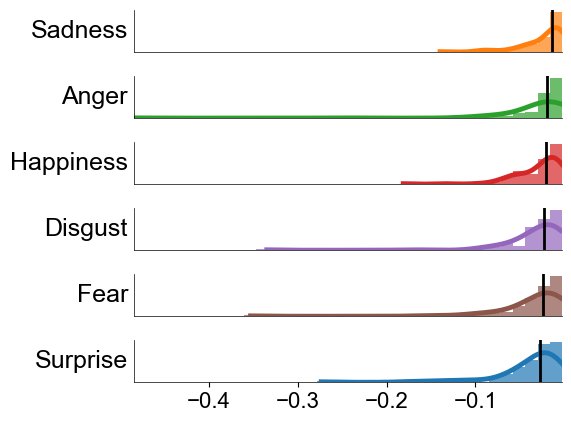

Inertia original


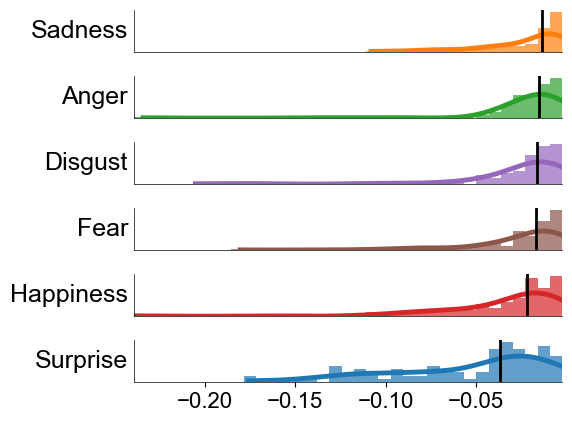

Instability fixed window + gaussian smoothing


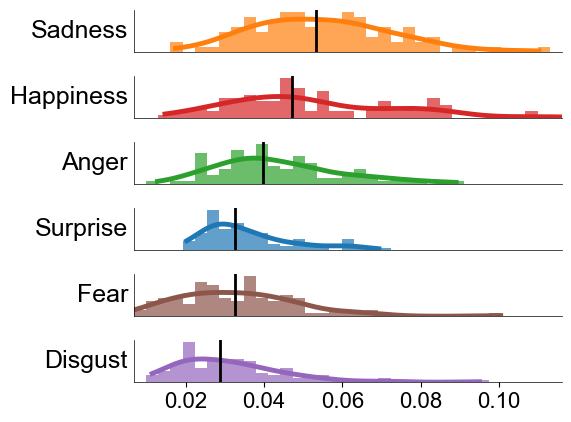

Instability original


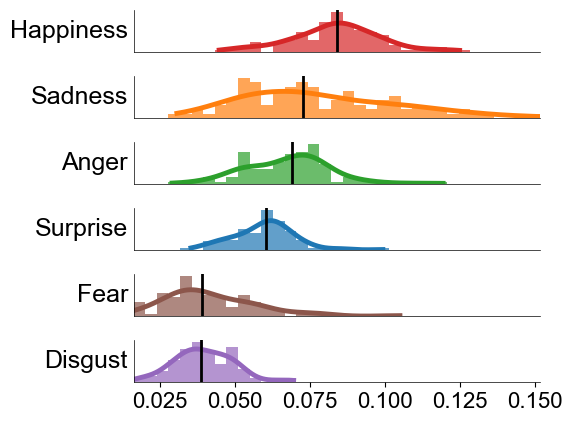

Hurst fixed window + gaussian smoothing


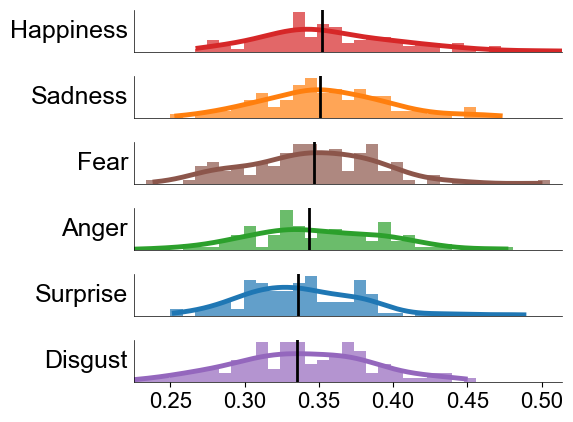

Hurst original


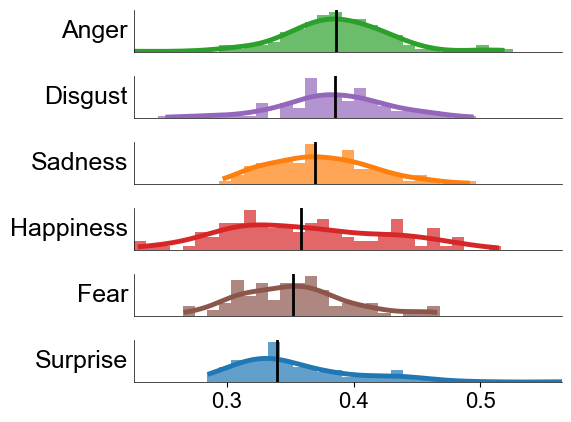

Average_controllability fixed window + gaussian smoothing


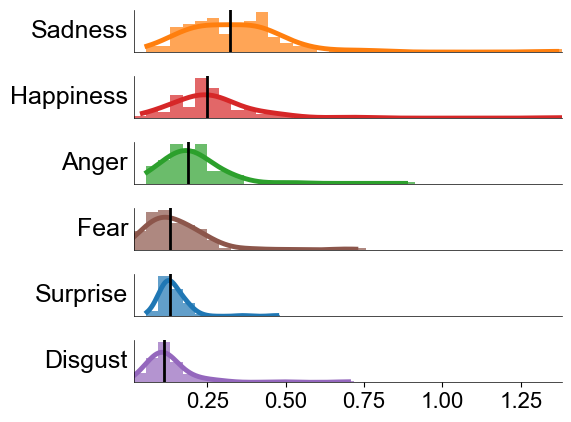

Average_controllability original


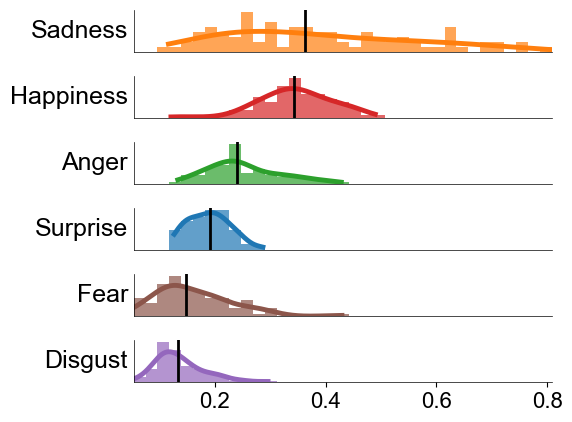

Modal_controllability fixed window + gaussian smoothing


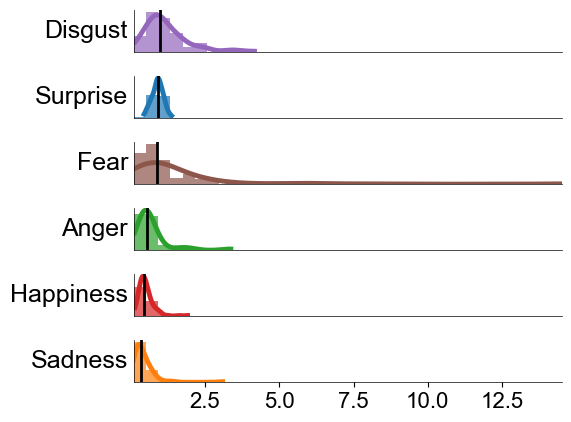

Modal_controllability original


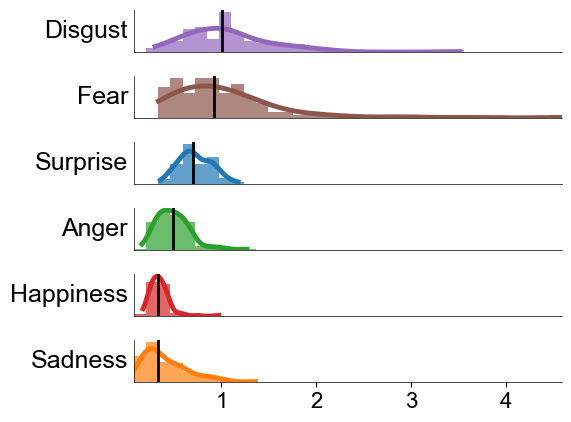

In [39]:
# min_seg_len: 100
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16

colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
features = [inertia_all, instability_all, Hurst_all, AC_all, MC_all]
features_ori = [inertia_all_pre[matched_index], instability_all_pre[matched_index], 
                Hurst_all_pre[matched_index], AC_all_pre_clean, MC_all_pre[matched_index]]
xlims = [[np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan]]
print(features[0].shape)
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
indices_name = [
    "Inertia",
    "Instability",
    "Hurst",
    "Average_controllability",
    "Modal_controllability",
] 
# emos = ['Ha', 'Su', 'Sa', 'An', 'Di', 'Fe']
for j in range(5):
    print(indices_name[j], 'fixed window + gaussian smoothing')
    plt.figure(figsize=(6,4.5))

    median = [np.nanmedian(features[j][:, i]) for i in range(6)]
    sorted_indices = np.argsort(median)[::-1]  

    all_data = np.concatenate([features[j][:, i] for i in range(6)], axis=0) 
    bin_edges = np.histogram(all_data[~np.isnan(all_data)], bins=35)[1]  
    
    for i, idx in enumerate(sorted_indices):  
        plt.subplot(6,1,i+1)

        plt.hist(features[j][:, idx], bins=bin_edges, color=colors[idx], alpha=0.7, density=True)

        kde = gaussian_kde(features[j][:, idx][~np.isnan(features[j][:, idx])])
        x = np.linspace(np.nanmin(features[j][:, idx]), np.nanmax(features[j][:, idx]), 1000)
        plt.plot(x, kde(x), color=colors[idx], linestyle='-', linewidth=3.5)

        median_val = np.nanmedian(features[j][:, idx])
        plt.axvline(median_val, color='black', linewidth=2, linestyle='-')

        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['bottom'].set_linewidth(0.5)
        plt.gca().spines['left'].set_linewidth(0.5)
        
        if i < 5: 
            plt.xticks([])
        plt.yticks([])

        if np.isnan(xlims[j][0]):
            plt.xlim([np.nanmin(features[j]), np.nanmax(features[j])])
        else:
            plt.xlim([xlims[j][0], xlims[j][1]])

        plt.ylabel(emos[idx], rotation=0, ha='right', va='center', fontsize=18)

    plt.tight_layout()
    plt.savefig('figures/%s_gs102.svg' % indices_name[j])
    plt.show()
    
    print(indices_name[j], 'original')
    plt.figure(figsize=(6,4.5))

    median = [np.nanmedian(features_ori[j][:, i]) for i in range(6)]
    sorted_indices = np.argsort(median)[::-1]  

    all_data = np.concatenate([features_ori[j][:, i] for i in range(6)], axis=0) 
    bin_edges = np.histogram(all_data[~np.isnan(all_data)], bins=35)[1]  
    
    for i, idx in enumerate(sorted_indices):  
        plt.subplot(6,1,i+1)

        plt.hist(features_ori[j][:, idx], bins=bin_edges, color=colors[idx], alpha=0.7, density=True)

        kde = gaussian_kde(features_ori[j][:, idx][~np.isnan(features_ori[j][:, idx])])
        x = np.linspace(np.nanmin(features_ori[j][:, idx]), np.nanmax(features_ori[j][:, idx]), 1000)
        plt.plot(x, kde(x), color=colors[idx], linestyle='-', linewidth=3.5)

        median_val = np.nanmedian(features_ori[j][:, idx])
        plt.axvline(median_val, color='black', linewidth=2, linestyle='-')

        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['bottom'].set_linewidth(0.5)
        plt.gca().spines['left'].set_linewidth(0.5)
        
        if i < 5: 
            plt.xticks([])
        plt.yticks([])

        if np.isnan(xlims[j][0]):
            plt.xlim([np.nanmin(features_ori[j]), np.nanmax(features_ori[j])])
        else:
            plt.xlim([xlims[j][0], xlims[j][1]])

        plt.ylabel(emos[idx], rotation=0, ha='right', va='center', fontsize=18)

    plt.tight_layout()
    plt.savefig('figures/%s_orismooth102.svg' % indices_name[j])
    plt.show()


(17, 6)
Inertia gaussian smoothing


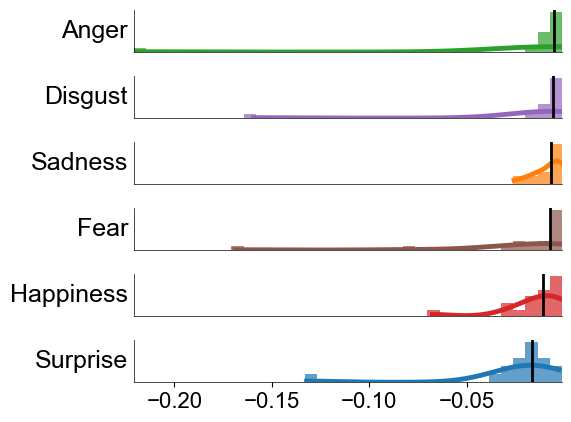

Inertia original smoothing


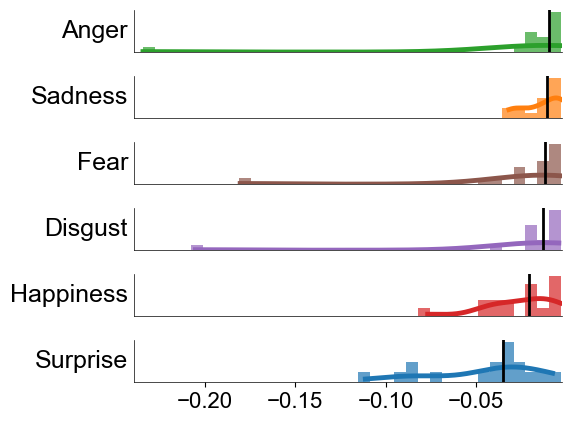

Instability gaussian smoothing


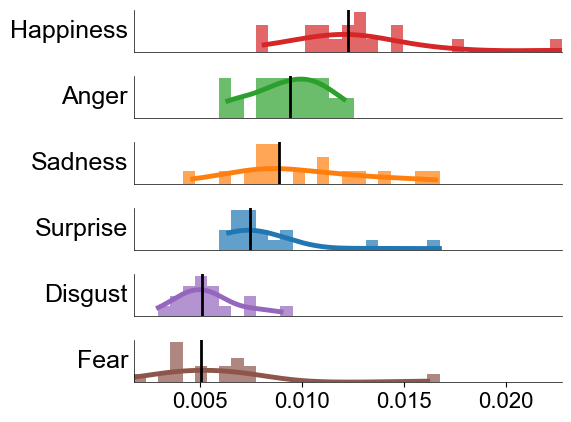

Instability original smoothing


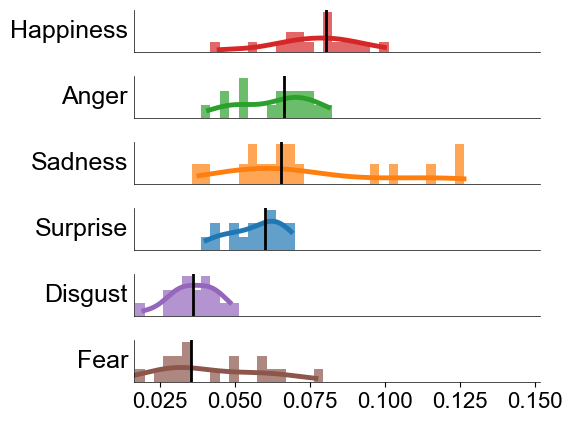

Hurst gaussian smoothing


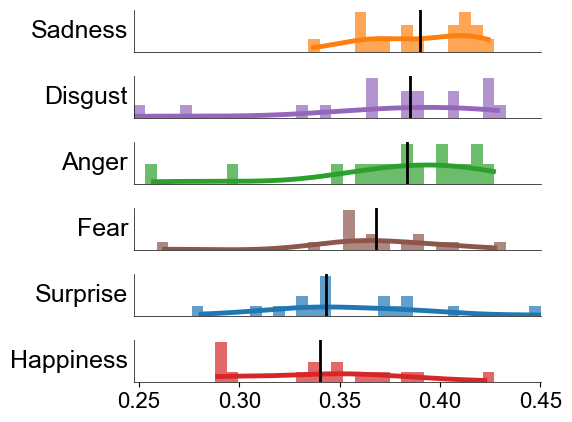

Hurst original smoothing


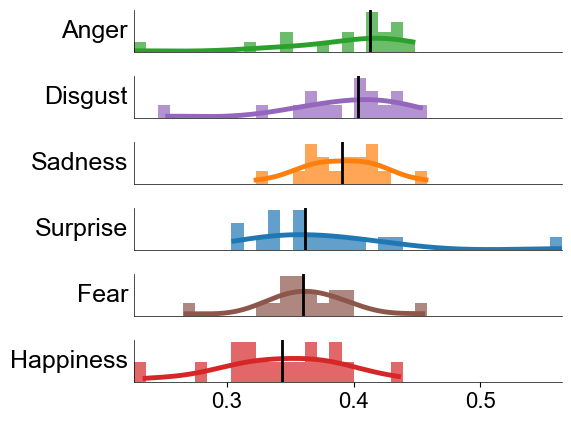

Average_controllability gaussian smoothing


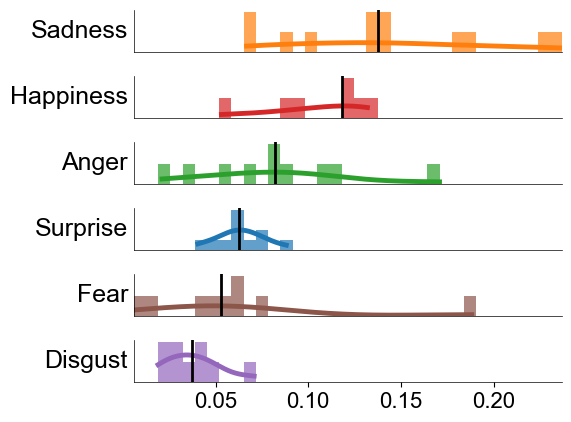

Average_controllability original smoothing


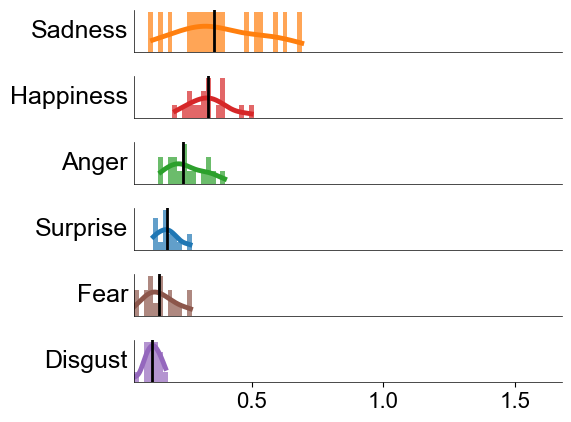

Modal_controllability gaussian smoothing


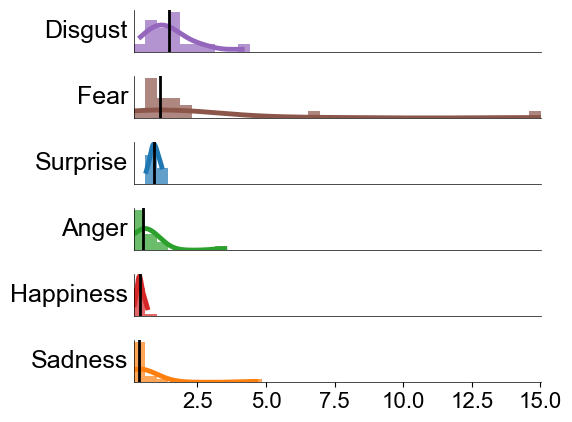

Modal_controllability original smoothing


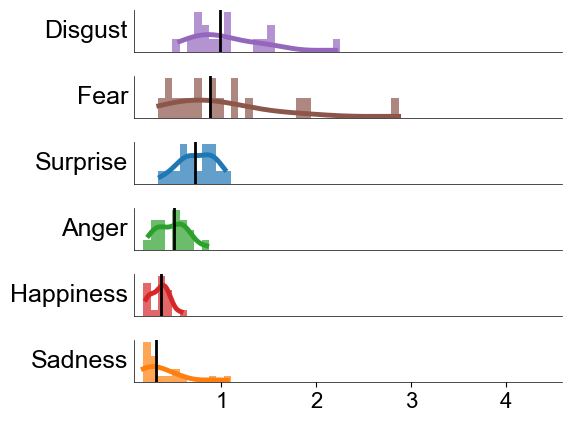

In [ ]:
# min_seg_len: 100
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 16

colors = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']
features = [inertia_all, instability_all, Hurst_all, AC_all, MC_all]
features_ori = [inertia_all_pre, instability_all_pre, Hurst_all_pre, AC_all_pre, MC_all_pre]
xlims = [[np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan], [np.nan, np.nan]]
print(features[0].shape)
emos = ["Happiness", "Surprise", "Sadness", "Anger", "Disgust", "Fear"]
indices_name = [
    "Inertia",
    "Instability",
    "Hurst",
    "Average_controllability",
    "Modal_controllability",
] 
# emos = ['Ha', 'Su', 'Sa', 'An', 'Di', 'Fe']
for j in range(5):
    print(indices_name[j], 'gaussian smoothing')
    plt.figure(figsize=(6,4.5))

    median = [np.nanmedian(features[j][:, i]) for i in range(6)]
    sorted_indices = np.argsort(median)[::-1]  

    all_data = np.concatenate([features[j][:, i] for i in range(6)], axis=0) 
    bin_edges = np.histogram(all_data[~np.isnan(all_data)], bins=35)[1]  
    
    for i, idx in enumerate(sorted_indices):  
        plt.subplot(6,1,i+1)

        plt.hist(features[j][:, idx], bins=bin_edges, color=colors[idx], alpha=0.7, density=True)

        kde = gaussian_kde(features[j][:, idx][~np.isnan(features[j][:, idx])])
        x = np.linspace(np.nanmin(features[j][:, idx]), np.nanmax(features[j][:, idx]), 1000)
        plt.plot(x, kde(x), color=colors[idx], linestyle='-', linewidth=3.5)

        median_val = np.nanmedian(features[j][:, idx])
        plt.axvline(median_val, color='black', linewidth=2, linestyle='-')

        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['bottom'].set_linewidth(0.5)
        plt.gca().spines['left'].set_linewidth(0.5)
        
        if i < 5: 
            plt.xticks([])
        plt.yticks([])

        if np.isnan(xlims[j][0]):
            plt.xlim([np.nanmin(features[j]), np.nanmax(features[j])])
        else:
            plt.xlim([xlims[j][0], xlims[j][1]])

        plt.ylabel(emos[idx], rotation=0, ha='right', va='center', fontsize=18)

    plt.tight_layout()
    plt.savefig('figures/%s_gs17.svg' % indices_name[j])
    plt.show()
    
    print(indices_name[j], 'original smoothing')
    plt.figure(figsize=(6,4.5))

    median = [np.nanmedian(features_ori[j][idx_reorder, i]) for i in range(6)]
    sorted_indices = np.argsort(median)[::-1]  

    all_data = np.concatenate([features_ori[j][idx_reorder, i] for i in range(6)], axis=0) 
    bin_edges = np.histogram(all_data[~np.isnan(all_data)], bins=35)[1]  
    
    for i, idx in enumerate(sorted_indices):  
        plt.subplot(6,1,i+1)

        plt.hist(features_ori[j][idx_reorder, idx], bins=bin_edges, color=colors[idx], alpha=0.7, density=True)

        kde = gaussian_kde(features_ori[j][idx_reorder, idx][~np.isnan(features_ori[j][idx_reorder, idx])])
        x = np.linspace(np.nanmin(features_ori[j][idx_reorder, idx]), np.nanmax(features_ori[j][idx_reorder, idx]), 1000)
        plt.plot(x, kde(x), color=colors[idx], linestyle='-', linewidth=3.5)

        median_val = np.nanmedian(features_ori[j][idx_reorder, idx])
        plt.axvline(median_val, color='black', linewidth=2, linestyle='-')

        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['bottom'].set_linewidth(0.5)
        plt.gca().spines['left'].set_linewidth(0.5)
        
        if i < 5: 
            plt.xticks([])
        plt.yticks([])

        if np.isnan(xlims[j][0]):
            plt.xlim([np.nanmin(features_ori[j]), np.nanmax(features_ori[j])])
        else:
            plt.xlim([xlims[j][0], xlims[j][1]])

        plt.ylabel(emos[idx], rotation=0, ha='right', va='center', fontsize=18)

    plt.tight_layout()
    plt.savefig('figures/%s_orismooth17.svg' % indices_name[j])
    plt.show()
